<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [2]:
import pandas as pd
import numpy as np

## Step 2. Import the dataset

In [4]:
data = pd.read_csv("50_Startups.csv");

In [6]:
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Step 3 . Check the State Column

In [8]:
data.State.value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [14]:
X = data.iloc[::, :4]
y = data.iloc[::, 4:]
print(X, sep = " ")

    R&D Spend  Administration  Marketing Spend       State
0   165349.20       136897.80        471784.10    New York
1   162597.70       151377.59        443898.53  California
2   153441.51       101145.55        407934.54     Florida
3   144372.41       118671.85        383199.62    New York
4   142107.34        91391.77        366168.42     Florida
5   131876.90        99814.71        362861.36    New York
6   134615.46       147198.87        127716.82  California
7   130298.13       145530.06        323876.68     Florida
8   120542.52       148718.95        311613.29    New York
9   123334.88       108679.17        304981.62  California
10  101913.08       110594.11        229160.95     Florida
11  100671.96        91790.61        249744.55  California
12   93863.75       127320.38        249839.44     Florida
13   91992.39       135495.07        252664.93  California
14  119943.24       156547.42        256512.92     Florida
15  114523.61       122616.84        261776.23    New Yo

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [18]:
x1 = pd.get_dummies( X, columns = ['State'] , drop_first = True )

In [20]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [17]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x1, y, test_size = 0.2, random_state = 42)


## Step 8  Import LinearRegression model from linear_model family 

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

## Step 9  Fit the data

In [30]:
print( model.fit(X_train, y_train) )

LinearRegression()


## Step 10  Predict the data

In [40]:
y_pred = model.predict(X_test)

In [48]:
accuracy = r2_score(y_test, y_pred)

print(f" the accuracy of the model is : {accuracy} ")

 the accuracy of the model is : 0.8987266414328637 


## Step 11  Display Result

In [52]:
import matplotlib.pyplot as plt
import seaborn as  sns

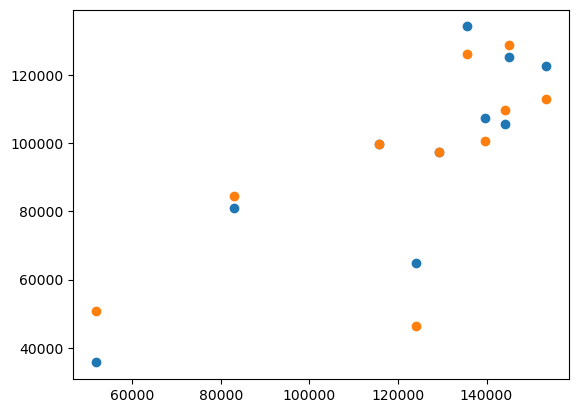

In [75]:
# y_test and y_predict

plt.scatter( X_test['Administration'], y_test )
plt.scatter( X_test['Administration'], y_pred )


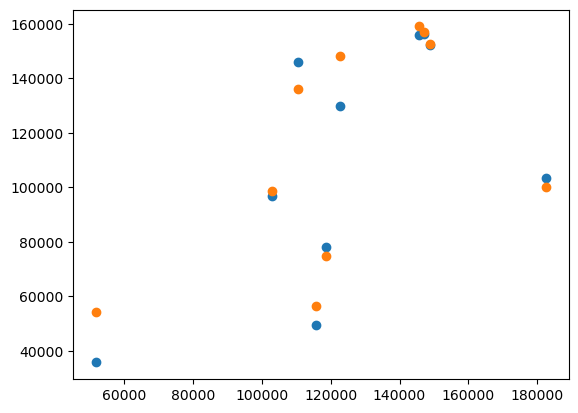

## RSS

In [77]:
np.sum( ( y_test.values - y_pred ) ** 2 )

820103630.4430103

865965493.677789

In [79]:
len(y_test)

10

10

In [97]:
from sklearn.metrics import mean_squared_error


In [114]:
mean_squared_error( y_test, y_pred ) * len(y_pred)


820103630.4430103

In [118]:
len(y_pred)

10

## R Square

In [120]:
from sklearn.metrics import r2_score

82010363.04430103

0.9522016331732872

In [154]:
accuracy = r2_score(y_test, y_pred)

print(f" the accuracy of the model is : {accuracy } ")

 the accuracy of the model is : 0.8987266414328637 


## Now use Polynomial Regression on Position_Salaries dataset

In [148]:
data2 = pd.read_csv("Position_Salaries.csv")

In [152]:
data2

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


Text(0.5, 1.0, ' Salary V/S Level ')

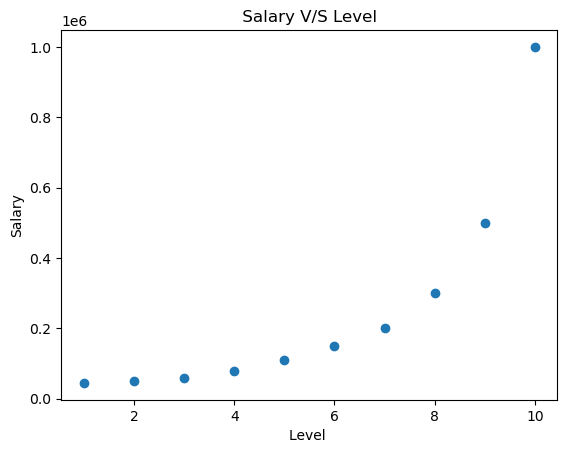

In [160]:
plt.scatter( data2.Level, data2.Salary )
plt.xlabel('Level ')
plt.ylabel('Salary')
plt.title( " Salary V/S Level " )

In [224]:
x = data2.iloc[::, 1:2:]
y = data2.Salary
x

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [179]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 42 )
X_train

,Level
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [186]:
from sklearn.preprocessing import PolynomialFeatures



In [260]:

poly = PolynomialFeatures( degree = 2)
#  here  degree  related to the degree of the varible : ex. X^2 + X + 2

In [262]:
x1 = poly.fit_transform(X_train)
x1

array([[  1.,   1.,   1.],
       [  1.,   8.,  64.],
       [  1.,   3.,   9.],
       [  1.,  10., 100.],
       [  1.,   5.,  25.],
       [  1.,   4.,  16.],
       [  1.,   7.,  49.]])

In [264]:
model2 = LinearRegression()
model2.fit( x1, y_train )

LinearRegression()

In [266]:
y_poly_predict = model2.predict( poly.fit_transform(X_test) )
y_poly_predict

array([652544.72066783,  37834.14365654, 141632.41904413])

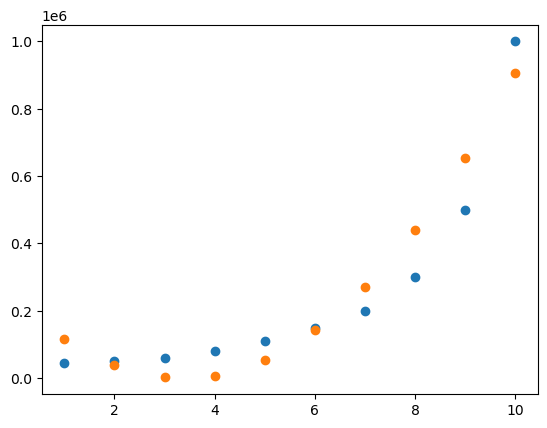

In [269]:
plt.scatter( data2.Level, data2.Salary )
temp = model2.predict(poly.fit_transform(x))
plt.scatter( data2.Level, temp )